# Lab 01 · Linear and logistic regression

**Audience:** master's students in Computer Science. **Time:** about 120 minutes.

- **Example A (35 minutes):** predict request latency with a simple linear model.
- **Example B (75 minutes):** predict latency-budget violations and choose an alert threshold.
- **Review (10 minutes):** explain errors and check the evaluation protocol.

The examples use original synthetic service data with fixed seeds. They are controlled
teaching examples, not measurements from a production service. No downloads are needed
after the course dependencies are installed.

**Deliverables:** complete tasks A1–A4 and B1–B5, run the notebook from a fresh kernel,
and fill in the written answers. Submit the executed notebook. Consult the accompanying
`lab_linear_logistic_regression.pdf` for the brief and assessment criteria.

## Solution version

All exercise cells are complete, with the same task identifiers and supplied checks
as the student notebook. Outputs are saved. Restart the kernel and run all cells to
reproduce them. Written answers explain the reasoning; exact decimals may vary slightly
between library versions. The logistic model is fitted on training data only and is
not refitted after its validation threshold is selected.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from scipy.special import expit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, accuracy_score,
    precision_score, recall_score, confusion_matrix, log_loss,
    ConfusionMatrixDisplay)

SEED = 42
plt.rcParams.update({"figure.figsize": (8, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.2, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11})
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")

Python 3.12.9 | NumPy 2.4.6 | scikit-learn 1.8.0


## Example A · How long will a request take?

A service processes requests of different sizes. Build a model whose input is
`size_mb` and whose target is `latency_ms`. The hidden average in this simulation is
linear, but individual requests vary. In a real system, the mean relationship is not
known in advance.

**Model:** predicted latency = intercept + slope × request size.

An intercept has units of milliseconds; a slope has units of milliseconds per MB.
The loss used for fitting is squared error. We will report MAE and RMSE on unseen
requests and compare with a model that always predicts the training mean.

In [2]:
# Supplied synthetic data. No model has been fitted yet.
rng_a = np.random.default_rng(7)
requests = pd.DataFrame({"size_mb": rng_a.uniform(0.5, 20, 120)})
requests["latency_ms"] = 25 + 5*requests["size_mb"] + rng_a.normal(0, 8, len(requests))
display(requests.head())
print("Observations:", len(requests))

,size_mb,latency_ms
0,12.689362,89.988775
1,17.995669,115.692797
2,15.625871,98.401128
3,4.891540,48.508822
4,6.353243,40.784242


Observations: 120


### A1

Create `Xa` as a DataFrame containing only `size_mb`, and `ya` as the `latency_ms` Series.
Split into `Xa_train`, `Xa_test`, `ya_train`, `ya_test` using `test_size=0.25` and
`random_state=SEED`. Keep the original row indices. Make a scatter plot of **training**
size against training latency, with axis labels and units. Describe the pattern before fitting.

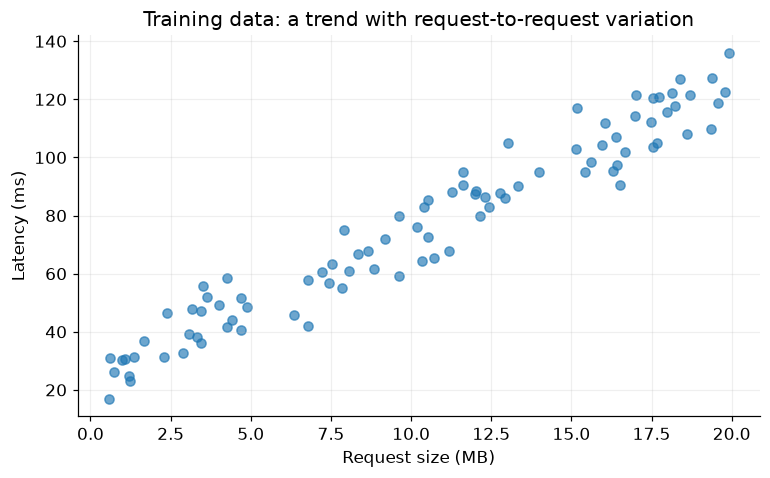

In [3]:
Xa = requests[["size_mb"]]
ya = requests["latency_ms"]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=0.25, random_state=SEED)
fig, ax = plt.subplots()
ax.scatter(Xa_train["size_mb"], ya_train, alpha=0.65)
ax.set(xlabel="Request size (MB)", ylabel="Latency (ms)", title="Training data: a trend with request-to-request variation")
plt.show()

In [4]:
# Supplied checks: keep the target out of the input features and the split disjoint.
assert list(Xa.columns) == ["size_mb"]
assert len(Xa_train) == 90 and len(Xa_test) == 30
assert set(Xa_train.index).isdisjoint(Xa_test.index)
assert Xa_train.index.equals(ya_train.index) and Xa_test.index.equals(ya_test.index)

### A2

Fit `linear_model = LinearRegression()` and `mean_model = DummyRegressor(strategy="mean")`
on training data. Create `pred_a` and `baseline_a`, their predictions on `Xa_test`.
Display the learned intercept and slope. Do not fit on `Xa_test` or use `ya_test.mean()`
for the baseline.

In [5]:
linear_model = LinearRegression().fit(Xa_train, ya_train)
mean_model = DummyRegressor(strategy="mean").fit(Xa_train, ya_train)
pred_a = linear_model.predict(Xa_test)
baseline_a = mean_model.predict(Xa_test)
print(f"Learned rule: latency ≈ {linear_model.intercept_:.2f} + "
      f"{linear_model.coef_[0]:.2f} × size (ms)")

Learned rule: latency ≈ 23.78 + 5.06 × size (ms)


In [6]:
assert np.asarray(pred_a).shape == (30,)
assert np.isfinite(pred_a).all()
assert np.allclose(baseline_a, ya_train.mean()), "Baseline must use the training mean."

### A3

Create `regression_results`, a DataFrame indexed by `Baseline` and `Linear regression`,
with columns `MAE_ms` and `RMSE_ms`. Compute both metrics on the same test rows.
RMSE is `np.sqrt(mean_squared_error(...))`. Plot training points, test points, the fitted
line, and the baseline over the observed size range. Label the axes and legend.

,MAE_ms,RMSE_ms
Baseline,20.936,24.465
Linear regression,5.852,7.074


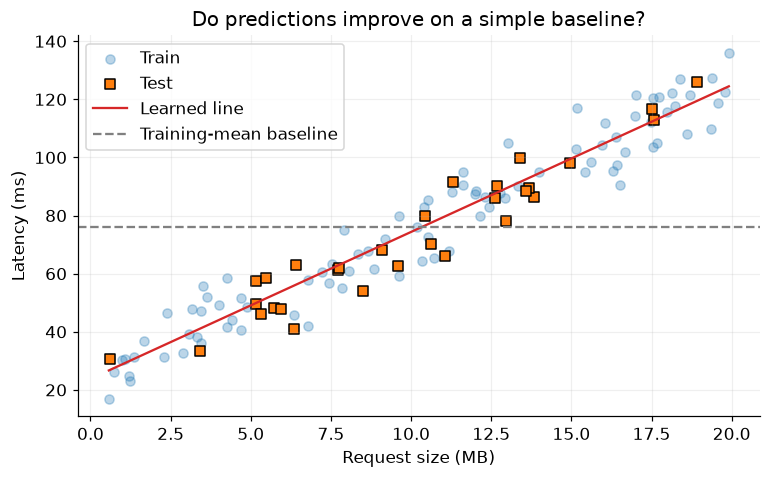

In [7]:
regression_results = pd.DataFrame({
    "MAE_ms": [mean_absolute_error(ya_test, baseline_a), mean_absolute_error(ya_test, pred_a)],
    "RMSE_ms": [np.sqrt(mean_squared_error(ya_test, baseline_a)), np.sqrt(mean_squared_error(ya_test, pred_a))],
}, index=["Baseline", "Linear regression"])
display(regression_results.round(3))
size_grid = pd.DataFrame({"size_mb": np.linspace(Xa.size_mb.min(), Xa.size_mb.max(), 150)})
fig, ax = plt.subplots()
ax.scatter(Xa_train.size_mb, ya_train, alpha=0.3, label="Train")
ax.scatter(Xa_test.size_mb, ya_test, marker="s", edgecolor="black", label="Test")
ax.plot(size_grid.size_mb, linear_model.predict(size_grid), color="tab:red", label="Learned line")
ax.axhline(ya_train.mean(), color="gray", ls="--", label="Training-mean baseline")
ax.set(xlabel="Request size (MB)", ylabel="Latency (ms)", title="Do predictions improve on a simple baseline?")
ax.legend()
plt.show()

**A3 discussion — explain your result.** Explain the intercept and slope with units. Does request size help on the test set?
Why are individual points allowed to miss the fitted line?

**Solution discussion:**

The intercept is the model's predicted latency at zero size, in milliseconds; the slope
is the added predicted milliseconds per extra MB. Zero is slightly outside this sample's
input range, so the intercept is an extrapolated value. Compare the displayed test errors:
using size substantially improves on predicting one constant. Individual requests contain
noise, so the line estimates a trend rather than promising an exact time for each request.

### A4

Create `residual_a = ya_test - pred_a`. Draw residuals against test request size and
include a horizontal zero line. Create `latency_4mb`, the predicted latency for a 4 MB
request, using a DataFrame with the same feature name as the training data.

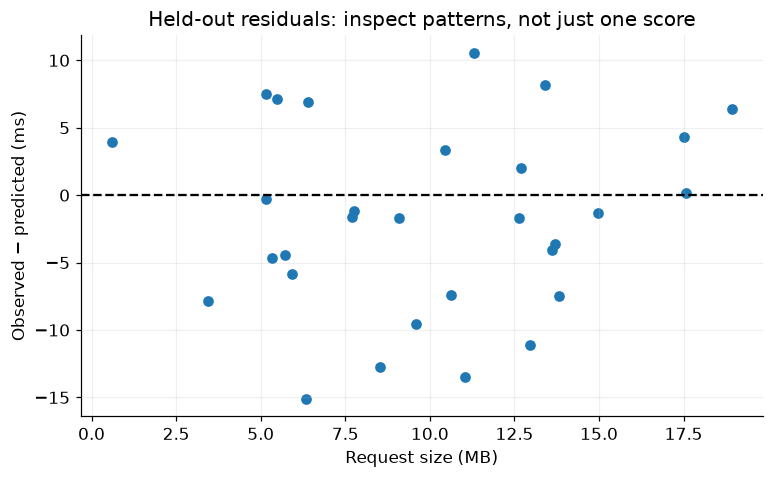

Prediction for 4 MB: 44.01 ms


In [8]:
residual_a = ya_test - pred_a
latency_4mb = float(linear_model.predict(pd.DataFrame({"size_mb": [4.0]}))[0])
fig, ax = plt.subplots()
ax.scatter(Xa_test.size_mb, residual_a)
ax.axhline(0, color="black", ls="--")
ax.set(xlabel="Request size (MB)", ylabel="Observed − predicted (ms)", title="Held-out residuals: inspect patterns, not just one score")
plt.show()
print(f"Prediction for 4 MB: {latency_4mb:.2f} ms")

**A4 discussion — explain your result.** What does a positive residual mean? Does the residual plot establish that every model
assumption is correct? Would you trust this line for a 1,000 MB request?

**Solution discussion:**

A positive residual means that the observed request was slower than predicted. A small
scatter without a clear pattern is consistent with a useful mean fit, but cannot prove
all assumptions from 30 test points. A 1,000 MB request is far outside the observed
range, where saturation or other effects could change the relationship. This plot is a
final diagnostic; redesigning a model based on these test errors would need a new final evaluation.

## Example B · Which requests should trigger a latency alert?

Before processing a request, predict whether it will exceed a latency budget. Each row
contains four features available at arrival:

| Feature | Meaning |
|---|---|
| `payload_mb` | Request payload in MB |
| `queue_length` | Number of requests already waiting |
| `cpu_percent` | CPU utilization at arrival, from 0 to 100 |
| `cache_hit` | Whether a cache lookup already found a reusable result (0/1) |

The target `budget_violation` is 1 for a slow request and 0 otherwise. These are synthetic
Bernoulli outcomes: even with all four inputs, the result has uncertainty. The generator
is supplied for transparency; do not use its internal score or probabilities as extra
features or as your model's predictions.

**Operational goal:** an alert is a positive decision. A false alert costs **1 unit**;
a missed violation costs **5 units**. Correct decisions cost zero. Compare total cost
`FP + 5 × FN` as well as accuracy, precision, and recall. A threshold of 0.5 is a
reference policy, not an automatically optimal choice.

In [9]:
# Supplied simulator. Four observed features; one stochastic outcome.
rng_b = np.random.default_rng(2026)
n_requests = 1200
traffic = pd.DataFrame({
    "payload_mb": np.clip(rng_b.lognormal(mean=2.0, sigma=0.7, size=n_requests), 0.5, 80),
    "queue_length": np.clip(rng_b.gamma(shape=2, scale=8, size=n_requests).astype(int), 0, 80),
    "cpu_percent": rng_b.uniform(10, 95, n_requests),
    "cache_hit": rng_b.binomial(1, 0.65, n_requests),
})
_simulation_score = (-4.8 + 0.08*traffic.payload_mb + 0.065*traffic.queue_length
                     + 0.04*traffic.cpu_percent - 1.0*traffic.cache_hit)
traffic["budget_violation"] = rng_b.binomial(1, expit(_simulation_score))
del _simulation_score  # The generator's hidden rule is not an input to the learning task.
FEATURES = ["payload_mb", "queue_length", "cpu_percent", "cache_hit"]
FP_COST, FN_COST = 1, 5
THRESHOLDS = np.round(np.arange(0.05, 1.0, 0.05), 2)
display(traffic.head())

,payload_mb,queue_length,cpu_percent,cache_hit,budget_violation
0,4.241064,59,30.762756,0,0
1,8.744281,20,93.556338,1,1
2,1.959269,37,88.268829,0,0
3,19.629631,18,49.256103,1,0
4,11.551396,0,33.342945,1,0


### B1

Select `Xb = traffic[FEATURES]` and `yb = traffic["budget_violation"]`.
First reserve 20% as `Xb_test`, `yb_test`, leaving `Xb_dev`, `yb_dev`. Then reserve 25%
of development rows as `Xb_val`, `yb_val`, leaving `Xb_train`, `yb_train`.
Use `random_state=SEED` and stratify on the corresponding target in **both** splits.
This gives a 60% / 20% / 20% train/validation/test split. Keep row indices intact.
Display the target counts and feature scales for **training data** only.

In [10]:
Xb = traffic[FEATURES]
yb = traffic["budget_violation"]
Xb_dev, Xb_test, yb_dev, yb_test = train_test_split(
    Xb, yb, test_size=0.2, stratify=yb, random_state=SEED)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    Xb_dev, yb_dev, test_size=0.25, stratify=yb_dev, random_state=SEED)
display(yb_train.value_counts().rename_axis("budget_violation").to_frame("Training count"))
display(Xb_train.agg(["mean", "std"]).round(2))
print("Train / validation / test:", len(Xb_train), len(Xb_val), len(Xb_test))

,Training count
budget_violation,
0,556
1,164


,payload_mb,queue_length,cpu_percent,cache_hit
mean,9.51,15.68,52.13,0.62
std,7.57,11.09,24.55,0.49


Train / validation / test: 720 240 240


In [11]:
assert [len(Xb_train), len(Xb_val), len(Xb_test)] == [720, 240, 240]
assert list(Xb_train.columns) == FEATURES
for left, right in [(Xb_train, Xb_val), (Xb_train, Xb_test), (Xb_val, Xb_test)]:
    assert set(left.index).isdisjoint(right.index), "Splits must not share rows."
assert set(Xb_train.index) | set(Xb_val.index) | set(Xb_test.index) == set(traffic.index)
for inputs, target in [(Xb_train,yb_train), (Xb_val,yb_val), (Xb_test,yb_test)]:
    assert inputs.index.equals(target.index)

**B1 discussion — explain your result.** Why is an always-no-alert baseline potentially accurate but operationally expensive?
Why does a random split suit this simulator but not necessarily real service logs?

**Solution discussion:**

Most requests do not violate the budget, so always predicting zero can have respectable
accuracy. It misses every actual violation, however, incurring the larger error cost.
The simulator generates independent requests under one stable rule; real logs may contain
time dependence, repeated clients, or workload changes, requiring temporal or group-aware evaluation.

### B2

Build `classifier_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))`.
Create `classifier_search = GridSearchCV(...)` with `logisticregression__C` in
`[0.01, 0.1, 1, 10]`, five-fold `StratifiedKFold(shuffle=True, random_state=SEED)`, and
`scoring="neg_log_loss"`. Fit it on `Xb_train, yb_train` **only**.
Set `selected_model = classifier_search.best_estimator_` and show the chosen C and
mean CV log loss for each candidate. The search's final refit remains within the training partition.

In [12]:
classifier_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
classifier_search = GridSearchCV(classifier_pipeline,
    {"logisticregression__C": [0.01, 0.1, 1, 10]},
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="neg_log_loss")
classifier_search.fit(Xb_train, yb_train)
selected_model = classifier_search.best_estimator_
print("Selected C:", classifier_search.best_params_["logisticregression__C"])
display(pd.DataFrame({"C": classifier_search.cv_results_["param_logisticregression__C"],
    "Mean CV log loss": -classifier_search.cv_results_["mean_test_score"]}).round(4))

Selected C: 1


,C,Mean CV log loss
0,0.01,0.4281
1,0.10,0.3780
2,1.00,0.3743
3,10.00,0.3744


In [13]:
assert np.allclose(selected_model.named_steps["standardscaler"].mean_, Xb_train.mean().to_numpy())
assert selected_model.named_steps["logisticregression"].classes_.tolist() == [0, 1]

**B2 discussion — explain your result.** Why place the scaler inside the pipeline passed to cross-validation? Does a smaller C
mean weaker or stronger regularization? Why choose C with a probability loss here?

**Solution discussion:**

Each fold must learn preprocessing from its own training rows. Scaling all rows before
cross-validation leaks validation information about feature distributions. Smaller C means
stronger regularization. Log loss evaluates probabilities, which will later support several
possible decision thresholds; accuracy at 0.5 would ignore probability confidence.

### B3

Create `val_probability = selected_model.predict_proba(Xb_val)[:, 1]` and
`val_labels_05` using threshold 0.5. Build `validation_summary_05`, a Series with
`accuracy`, `precision`, `recall`, and `log_loss`. Use `zero_division=0` for precision
and recall. Draw probability histograms for actual negative and positive validation
requests on common bins, and mark threshold 0.5.

accuracy     0.8208
precision    0.6875
recall       0.4000
log_loss     0.4374
dtype: float64

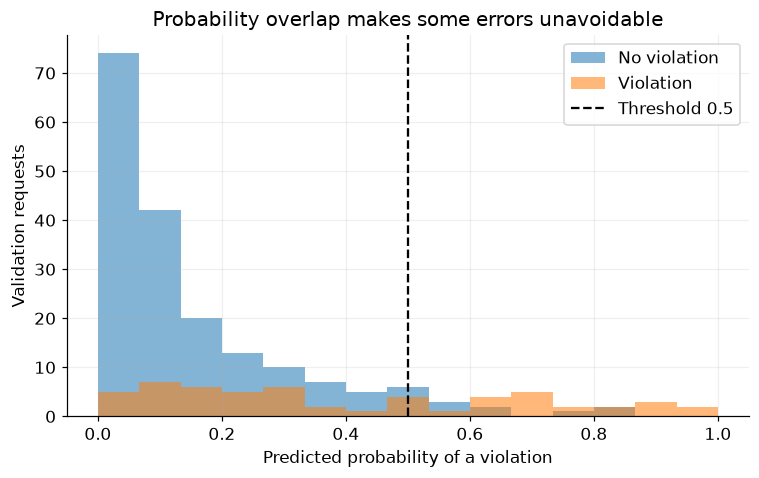

In [14]:
val_probability = selected_model.predict_proba(Xb_val)[:, 1]
val_labels_05 = (val_probability >= 0.5).astype(int)
validation_summary_05 = pd.Series({
    "accuracy": accuracy_score(yb_val, val_labels_05),
    "precision": precision_score(yb_val, val_labels_05, zero_division=0),
    "recall": recall_score(yb_val, val_labels_05, zero_division=0),
    "log_loss": log_loss(yb_val, val_probability),
})
display(validation_summary_05.round(4))
fig, ax = plt.subplots()
for label, name in [(0,"No violation"),(1,"Violation")]:
    ax.hist(val_probability[yb_val.to_numpy() == label], bins=np.linspace(0,1,16), alpha=0.55, label=name)
ax.axvline(0.5, color="black", ls="--", label="Threshold 0.5")
ax.set(xlabel="Predicted probability of a violation", ylabel="Validation requests", title="Probability overlap makes some errors unavoidable")
ax.legend()
plt.show()

In [15]:
assert val_probability.shape == (240,)
assert np.isfinite(val_probability).all() and ((val_probability >= 0) & (val_probability <= 1)).all()

### B4

For each value in `THRESHOLDS`, convert validation probabilities to labels with `>=`.
Create `threshold_results` with columns `threshold`, `FP`, `FN`, and `cost`, where
`cost = FP_COST*FP + FN_COST*FN`. Use `confusion_matrix(..., labels=[0, 1]).ravel()`
to obtain `tn, fp, fn, tp`. Choose `best_threshold` with the smallest validation cost;
**if costs tie, choose the largest threshold**. Plot validation cost against threshold,
mark the selection, and display FP/FN counts at 0.5 and at the selected threshold.
Do not use test predictions or test labels for this task.

Frozen decision threshold: 0.1


,FP,FN,cost
threshold,,,
0.1,85,8,125
0.5,10,33,175


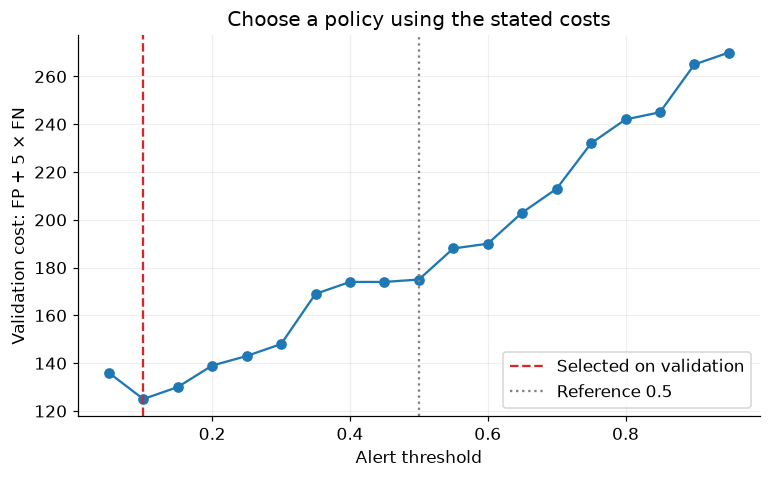

In [16]:
rows = []
for threshold in THRESHOLDS:
    labels = (val_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_val, labels, labels=[0,1]).ravel()
    rows.append({"threshold": threshold, "FP": fp, "FN": fn, "cost": FP_COST*fp + FN_COST*fn})
threshold_results = pd.DataFrame(rows)
best_threshold = float(threshold_results.sort_values(["cost","threshold"], ascending=[True,False]).iloc[0]["threshold"])
print("Frozen decision threshold:", best_threshold)
display(threshold_results[threshold_results.threshold.isin([0.5, best_threshold])].set_index("threshold"))
fig, ax = plt.subplots()
ax.plot(threshold_results.threshold, threshold_results.cost, "o-")
ax.axvline(best_threshold, color="tab:red", ls="--", label="Selected on validation")
ax.axvline(0.5, color="gray", ls=":", label="Reference 0.5")
ax.set(xlabel="Alert threshold", ylabel="Validation cost: FP + 5 × FN", title="Choose a policy using the stated costs")
ax.legend()
plt.show()

In [17]:
assert len(threshold_results) == len(THRESHOLDS)
assert np.allclose(threshold_results["cost"], FP_COST*threshold_results.FP + FN_COST*threshold_results.FN)
minimum_cost = threshold_results["cost"].min()
assert best_threshold == threshold_results.loc[threshold_results.cost == minimum_cost, "threshold"].max()

**B4 discussion — explain your result.** Explain the selected threshold's tradeoff relative to 0.5. Why is a lower validation
cost not a guarantee of the same improvement on test data? Does changing the threshold
change the probabilities?

**Solution discussion:**

Because missed violations cost five times as much, the selected policy usually alerts
at probabilities below 0.5. It accepts extra false alerts to miss fewer violations.
The validation sample is finite and the threshold was selected to look good on it;
its estimated gain can be optimistic. Changing the threshold leaves the fitted probability
model unchanged. On a fixed set of probabilities, lowering the threshold cannot decrease
recall, but precision need not change monotonically.

### Freeze before the final evaluation

At this point both the model and `best_threshold` are fixed. **Do not refit on train +
validation** in this lab: a refit could change the probability scale and the meaning of
the selected threshold. Evaluate these three predeclared policies on the same test set:

1. Always predict no alert.
2. The fitted logistic model with threshold 0.5.
3. The same fitted logistic model with `best_threshold`.

The two logistic policies have identical probability predictions and log loss. Their
confusion matrices, accuracy, precision, recall, and cost can differ. We do not report
log loss for the always-negative hard-decision baseline: its purpose here is a policy-cost comparison.

### B5

Create `test_probability` once from `selected_model` and `Xb_test`.
Create `test_results`, indexed by `Always no alert`, `Threshold 0.5`, and
`Validation threshold`, with columns `accuracy`, `precision`, `recall`, `FP`, `FN`,
`cost`, and `cost_per_request`. Use the three predeclared policies above.
Print the logistic model's test log loss separately. Plot the two logistic confusion
matrices side by side with labels `No violation` and `Violation`. Do not retune anything
in response to the test comparison.

,accuracy,precision,recall,FP,FN,cost,cost_per_request
policy,,,,,,,
Always no alert,0.7708,0.0000,0.0000,0,55,275,1.1458
Threshold 0.5,0.7875,0.5500,0.4000,18,33,183,0.7625
Validation threshold,0.5792,0.3446,0.9273,97,4,117,0.4875


Test log loss (same probability model for both thresholds): 0.4391


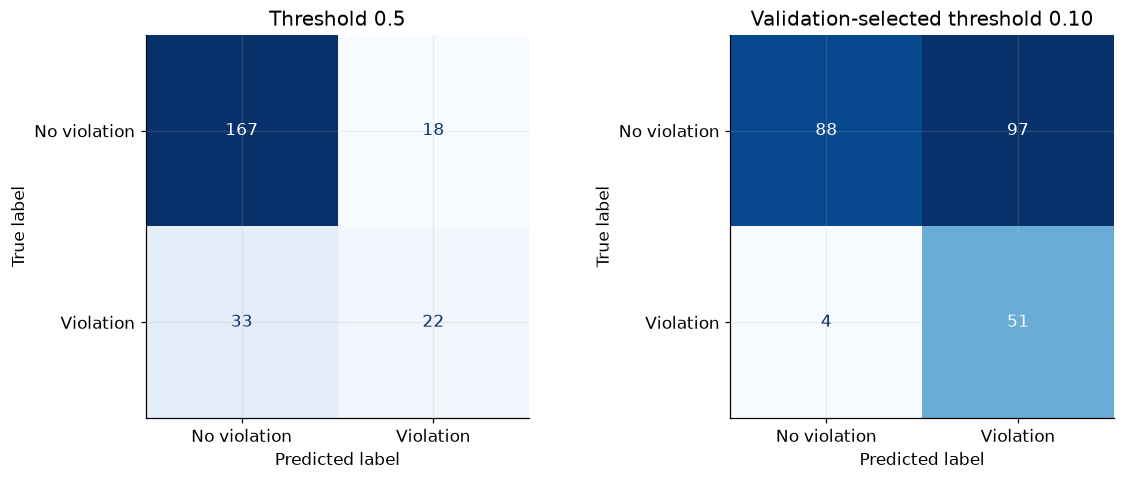

In [18]:
test_probability = selected_model.predict_proba(Xb_test)[:,1]
policies = {
    "Always no alert": np.zeros(len(yb_test), dtype=int),
    "Threshold 0.5": (test_probability >= 0.5).astype(int),
    "Validation threshold": (test_probability >= best_threshold).astype(int),
}
rows = []
for name, labels in policies.items():
    tn, fp, fn, tp = confusion_matrix(yb_test, labels, labels=[0,1]).ravel()
    cost = FP_COST*fp + FN_COST*fn
    rows.append({"policy": name, "accuracy": accuracy_score(yb_test, labels),
        "precision": precision_score(yb_test, labels, zero_division=0),
        "recall": recall_score(yb_test, labels, zero_division=0),
        "FP": fp, "FN": fn, "cost": cost, "cost_per_request": cost/len(yb_test)})
test_results = pd.DataFrame(rows).set_index("policy")
display(test_results.round(4))
print("Test log loss (same probability model for both thresholds):", round(log_loss(yb_test,test_probability),4))
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for ax, name in zip(axes,["Threshold 0.5","Validation threshold"]):
    ConfusionMatrixDisplay.from_predictions(yb_test, policies[name], display_labels=["No violation","Violation"],
        labels=[0,1], cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name if name == "Threshold 0.5" else f"Validation-selected threshold {best_threshold:.2f}")
plt.tight_layout()
plt.show()

In [19]:
assert test_probability.shape == (240,)
assert test_results.index.tolist() == ["Always no alert", "Threshold 0.5", "Validation threshold"]
assert np.allclose(test_results.cost_per_request, test_results.cost/len(yb_test))
assert test_results.loc["Always no alert", "recall"] == 0
assert test_results.loc["Always no alert", "cost"] == FN_COST * int(yb_test.sum())
# Test performance is evidence, not a condition to optimize until this notebook passes.

**B5 discussion — explain your result.** Recommend a policy under the stated costs, referring to the validation choice and the
held-out evidence. Is the highest-accuracy policy also the lowest-cost one? Explain
why the two logistic policies share log loss, and name one limitation of this experiment.

**Solution discussion:**

The validation-selected policy is the preselected candidate for the stated cost objective;
use the final table to report whether its test cost supports that choice. In the supplied
run the validation-selected threshold is 0.10. On test data it reduces cost from 183
to 117 units versus threshold 0.5, while accuracy falls from about 78.8% to 57.9%.
It misses 4 violations instead of 33, but produces 97 false alerts instead of 18. Both logistic policies use the same probabilities, and log
loss does not use the classification threshold. This is a small, stationary synthetic
experiment: real deployments require representative data, credible cost assumptions,
and checks for shifts in workload or probability calibration. Do not select a new
threshold after inspecting these test results.

## Optional discussion (not required for completion)

1. If false positives cost five units and false negatives cost one, which direction
   would you expect the threshold to move? Investigate using validation data only.
2. With calibrated probabilities and costs `c_FP` and `c_FN`, compare the expected cost
   of the two decisions and show why the theoretical threshold is
   `c_FP / (c_FP + c_FN)`. Why might a finite validation-grid optimum differ?
3. If the same client submits many correlated requests, how should the splitting
   strategy change? What if CPU behavior changes after a software deployment?

## Submission checklist

- Complete all nine TODO cells and six written-answer prompts.
- Keep the supplied seeds, features, split sizes, threshold grid, and error costs.
- Show labeled figures and the regression, validation, and test comparison tables.
- Restart and run the completed notebook from top to bottom; keep outputs saved.
- Explain errors in milliseconds for A and in decision consequences for B.

**References:** the examples and simulators are original for this lab. API background:
[linear models](https://scikit-learn.org/stable/modules/linear_model.html),
[pipelines](https://scikit-learn.org/stable/modules/compose.html), and
[model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html).
The companion course notebook supplies the conceptual explanations.

### Solution notes for the optional discussion

1. Making false alerts more expensive generally favors a higher threshold. Check that
   tradeoff on the validation set; do not use repeated test comparisons to choose it.
2. Predicting positive has expected cost `c_FP × (1 − p)` and predicting negative has
   expected cost `c_FN × p`. The first is smaller when `p > c_FP / (c_FP + c_FN)`.
   With costs 1 and 5 the ideal calibrated threshold is about 0.167. A finite validation
   sample, an imperfect probability model, and a discrete grid can select a different
   value; the 0.10 selected here is an empirical policy, not a mathematical contradiction.
3. Separate clients across folds when future generalization to unseen clients is the
   goal. For forecasting future workloads, use chronological splits and keep feature
   timestamps honest. A deployment change can shift input distributions or the relationship
   between inputs and outcomes; previous validation results may no longer describe it.
